PHIÊN BẢN SỬ DỤNG:
- Python version: 3.10.0  
- MediaPipe version: 0.10.14

Check số lượng folder trong dataset

In [1]:
import os

DATASET = "dataset/hmdb51"
labels = [
    d for d in os.listdir(DATASET)
    if os.path.isdir(os.path.join(DATASET, d))
]

print("Number of labels:", len(labels))
print(labels[:])

Number of labels: 51
['brush_hair', 'cartwheel', 'catch', 'chew', 'clap', 'climb', 'climb_stairs', 'dive', 'draw_sword', 'dribble', 'drink', 'eat', 'fall_floor', 'fencing', 'flic_flac', 'golf', 'handstand', 'hit', 'hug', 'jump', 'kick', 'kick_ball', 'kiss', 'laugh', 'pick', 'pour', 'pullup', 'punch', 'push', 'pushup', 'ride_bike', 'ride_horse', 'run', 'shake_hands', 'shoot_ball', 'shoot_bow', 'shoot_gun', 'sit', 'situp', 'smile', 'smoke', 'somersault', 'stand', 'swing_baseball', 'sword', 'sword_exercise', 'talk', 'throw', 'turn', 'walk', 'wave']


Import thư viện

In [2]:
import os
import cv2
import numpy as np
import mediapipe as mp
from tqdm import tqdm
import torch
import random

Khởi tạo MediaPipe và trích xuất dữ liệu

# khởi tạo pose bằng mp.solution
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)

DATASET_PATH = 'dataset/hmdb51'
OUTPUT_PATH = 'pose' 

def extract_skeleton_from_video(video_path, save_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Không thể mở video {video_path}")
        return

    video_skeleton = []
    
    # trích từng frame
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # MediaPipe yêu cầu định dạng RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(frame_rgb)
        
        if results.pose_landmarks:
            # lấy tọa độ 33 khớp xương (x, y, visibility)
            keypoints = np.array([[lm.x, lm.y, lm.visibility] for lm in results.pose_landmarks.landmark])
        else:
            # padding 0 nếu không recognize được người
            keypoints = np.zeros((33, 3))
            
        video_skeleton.append(keypoints)
        
    cap.release()
    
    if len(video_skeleton) == 0:
        return

    video_skeleton = np.array(video_skeleton)
    np.save(save_path, video_skeleton)

# duyệt qua các video và trích data
print(f"Bắt đầu trích xuất trực tiếp từ video tại: {DATASET_PATH}")
classes = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]

for action_class in tqdm(classes, desc="Processing Classes"):
    class_dir = os.path.join(DATASET_PATH, action_class)
    output_class_dir = os.path.join(OUTPUT_PATH, action_class)
    
    os.makedirs(output_class_dir, exist_ok=True)
    videos = [v for v in os.listdir(class_dir) if v.endswith(('.avi', '.mp4'))]
    
    for video_name in videos:
        video_path = os.path.join(class_dir, video_name)
        
        # đổi đuôi .avi thành .npy
        save_name = video_name.rsplit('.', 1)[0] + ".npy"
        save_path = os.path.join(output_class_dir, save_name)
        
        # resume video
        if not os.path.exists(save_path):
            extract_skeleton_from_video(video_path, save_path)

print(f"HOÀN TẤT! Dữ liệu khung xương đã được lưu tại: {OUTPUT_PATH}")

Custom dataset và DatasetLoader

In [3]:
from torch.utils.data import Dataset, DataLoader

# cấu hình
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

OUTPUT_PATH = 'pose'
# chuẩn hóa
NUM_FRAMES = 64
BATCH_SIZE = 16

# xây class SkeletonDataset
class SkeletonDataset(Dataset):
    def __init__(self, data_list, num_frames=NUM_FRAMES):
        self.data_list = data_list
        self.num_frames = num_frames

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        file_path, label = self.data_list[idx]
        
        # shape gốc: (T_gốc, 33, 3)
        skeleton = np.load(file_path)
        t_orig = skeleton.shape[0]

        # sampling/padding
        if t_orig == 0:
            # nếu video lỗi không trích xuất được người, padding 0
            skeleton_sampled = np.zeros((self.num_frames, 33, 3))
        elif t_orig >= self.num_frames:
            # lấy mẫu đều đặn để nén video dài xuống 64 frames
            indices = np.linspace(0, t_orig - 1, self.num_frames, dtype=int)
            skeleton_sampled = skeleton[indices]
        else:
            # nếu video ngắn, copy frame cuối để bù cho đủ 64 frames
            pad_len = self.num_frames - t_orig
            pad_frames = np.repeat(skeleton[-1:], pad_len, axis=0)
            skeleton_sampled = np.concatenate((skeleton, pad_frames), axis=0)
            
        # biến đổi tensor cho st-gcn: (T, V, C) -> (C, T, V, M)
        # C = 3 (x, y, visibility)
        # T = 64 (frame)
        # V = 33 (khớp xương)
        # M = 1 (người)
        
        # đảo chiều T, 33, 3 thành 3, T, 33
        skeleton_transposed = np.transpose(skeleton_sampled, (2, 0, 1))
        
        # thêm chiều M vào cuối mảng thành 3, T, 33, 1
        skeleton_final = np.expand_dims(skeleton_transposed, axis=-1)
        
        # chuyển thành PyTorch Tensor
        tensor_data = torch.tensor(skeleton_final, dtype=torch.float32)
        tensor_label = torch.tensor(label, dtype=torch.long)
        
        return tensor_data, tensor_label

# train/val/test split
all_classes = sorted(os.listdir(OUTPUT_PATH))
class_to_idx = {cls_name: i for i, cls_name in enumerate(all_classes)}

all_data = []
for cls_name in all_classes:
    cls_dir = os.path.join(OUTPUT_PATH, cls_name)
    for file_name in os.listdir(cls_dir):
        if file_name.endswith('.npy'):
            all_data.append((os.path.join(cls_dir, file_name), class_to_idx[cls_name]))

# xáo random theo seed = 42
random.shuffle(all_data)

# cắt theo 80 - 10 - 10
total_size = len(all_data)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)

train_data = all_data[:train_size]
val_data = all_data[train_size:train_size+val_size]
test_data = all_data[train_size+val_size:]

# dataloader
train_loader = DataLoader(SkeletonDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SkeletonDataset(val_data), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SkeletonDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

# in kqua
print(f"Tổng số video đọc được: {total_size}")
print(f"Tập Train: {len(train_data)} | Tập Val: {len(val_data)} | Tập Test: {len(test_data)}")

# check shape 1 batch
sample_batch_data, sample_batch_labels = next(iter(train_loader))
print(f"Shape dữ liệu (N, C, T, V, M): {sample_batch_data.shape}")
print(f"Shape nhãn: {sample_batch_labels.shape}")

Tổng số video đọc được: 6754
Tập Train: 5403 | Tập Val: 675 | Tập Test: 676
Shape dữ liệu (N, C, T, V, M): torch.Size([16, 3, 64, 33, 1])
Shape nhãn: torch.Size([16])


Tạo đồ thị MediaPipe và mô hình ST-GCN

In [4]:
import torch.nn as nn
import torch.nn.functional as F

# khai báo đồ thị 
class Graph():
    def __init__(self):
        self.num_node = 33
        self.edges = [
            # đầu, mặt
            (0,1), (1,2), (2,3), (3,7), (0,4), (4,5), (5,6), (6,8), (9,10),
            # thân
            (11,12), (11,23), (12,24), (23,24),
            # tay trái
            (11,13), (13,15), (15,17), (15,19), (15,21), (17,19),
            # tay phải
            (12,14), (14,16), (16,18), (16,20), (16,22), (18,20),
            # chân trái
            (23,25), (25,27), (27,29), (29,31), (27,31),
            # chân phải
            (24,26), (26,28), (28,30), (30,32), (28,32)
        ]
        # lấy điểm 0 (mũi) làm trọng tâm để tính khoảng cách hướng tâm/ly tâm
        self.center = 0 
        self.A = self.get_spatial_graph()

    def get_spatial_graph(self):
        # tạo ma trận kề cơ bản
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edges:
            A[i, j] = 1
            A[j, i] = 1
            
        # tính khoảng cách từ mỗi node tới node 0 (center)
        distance_to_center = np.full(self.num_node, np.inf)
        distance_to_center[self.center] = 0
        visited = [self.center]
        queue = [self.center]
        
        while queue:
            node = queue.pop(0)
            for neighbor in range(self.num_node):
                if A[node, neighbor] == 1 and neighbor not in visited:
                    distance_to_center[neighbor] = distance_to_center[node] + 1
                    visited.append(neighbor)
                    queue.append(neighbor)

        # phân hoạch làm 3 ma trận: 0 (local), 1 (hướng tâm), 2 (ly tâm)
        A_split = np.zeros((3, self.num_node, self.num_node))
        for i in range(self.num_node):
            for j in range(self.num_node):
                if A[i, j] == 1 or i == j:
                    if distance_to_center[i] == distance_to_center[j]:
                        A_split[0, i, j] = 1
                    elif distance_to_center[i] < distance_to_center[j]:
                        A_split[1, i, j] = 1
                    else:
                        A_split[2, i, j] = 1

        # chuẩn hóa ma trận
        for k in range(3):
            D = np.sum(A_split[k], axis=1)
            D[D == 0] = 1
            D_inv = np.diag(D ** -0.5)
            A_split[k] = np.dot(np.dot(D_inv, A_split[k]), D_inv)
            
        return torch.tensor(A_split, dtype=torch.float32)

# tích chập đồ thị không gian
class GraphConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, s_kernel=3):
        super().__init__()
        self.s_kernel = s_kernel
        self.conv = nn.Conv2d(in_channels, out_channels * s_kernel, kernel_size=1)

    def forward(self, x, A):
        # x: (N, C, T, V)
        # A: (3, V, V)
        x = self.conv(x)
        n, kc, t, v = x.size()
        x = x.view(n, self.s_kernel, kc // self.s_kernel, t, v)
        
        # áp dụng công thức ST-GCN gốc: Nhân với ma trận 3D A
        x = torch.einsum('nkctv,kvw->nctw', (x, A))
        return x.contiguous()

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dropout=0.5):
        super().__init__()
        
        # Spatial Conv (tchập kgian)
        self.gcn = GraphConvolution(in_channels, out_channels)
        self.tcn_bn1 = nn.BatchNorm2d(out_channels)
        
        # Temporal Conv (tchập tgian)
        self.tcn = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, (kernel_size, 1), (stride, 1), padding=((kernel_size - 1) // 2, 0)),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(dropout) # Thêm dropout chống overfit
        )
        
        # Residual connection (tránh nghẽn mạng)
        if in_channels != out_channels or stride != 1:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.residual = lambda x: x
            
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, A):
        res = self.residual(x)
        x = self.tcn_bn1(self.gcn(x, A))
        x = self.tcn(x)
        return self.relu(x + res)

# ST-GCN hoàn chỉnh
class STGCN(nn.Module):
    def __init__(self, num_class=51, in_channels=3, dropout=0.5):
        super().__init__()
        
        self.graph = Graph()
        self.register_buffer('A', self.graph.A)
        
        # chuẩn hóa
        self.data_bn = nn.BatchNorm1d(in_channels * self.graph.num_node)
        
        # mạng lưới các block ST-GCN
        self.st_gcn_networks = nn.ModuleList([
            STGCNBlock(in_channels, 64, kernel_size=9, stride=1, dropout=dropout),
            STGCNBlock(64, 64, kernel_size=9, stride=1, dropout=dropout),
            STGCNBlock(64, 64, kernel_size=9, stride=1, dropout=dropout),
            STGCNBlock(64, 128, kernel_size=9, stride=2, dropout=dropout),
            STGCNBlock(128, 128, kernel_size=9, stride=1, dropout=dropout),
            STGCNBlock(128, 128, kernel_size=9, stride=1, dropout=dropout),
            STGCNBlock(128, 256, kernel_size=9, stride=2, dropout=dropout),
            STGCNBlock(256, 256, kernel_size=9, stride=1, dropout=dropout),
            STGCNBlock(256, 256, kernel_size=9, stride=1, dropout=dropout),
        ])
        
        # trọng số quan trọng
        self.edge_importance = nn.ParameterList([
            nn.Parameter(torch.ones(self.graph.A.size()))
            for _ in self.st_gcn_networks
        ])
            
        self.fc = nn.Linear(256, num_class)
        self.final_dropout = nn.Dropout(p=dropout) # chống overfit trước khi dự đoán

    def forward(self, x):
        # bỏ chiều M
        x = x.squeeze(-1) 
        
        # chuẩn hóa
        N, C, T, V = x.size()
        x = x.permute(0, 3, 1, 2).contiguous() # (N, V, C, T)
        x = x.view(N, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, V, C, T).permute(0, 2, 3, 1).contiguous() # trả về (N, C, T, V)
        
        # Chạy qua các layer ST-GCN
        for gcn, importance in zip(self.st_gcn_networks, self.edge_importance):
            x = gcn(x, self.A * importance)
            
        # global pooling (avg kgian & tgian)
        x = F.avg_pool2d(x, x.size()[2:])
        x = x.view(N, -1)
        
        # phân loại
        x = self.final_dropout(x)
        x = self.fc(x)
        return x

# Chạy test thử cấu trúc
if __name__ == "__main__":
    dummy_input = torch.randn(16, 3, 64, 33, 1) # (N, C, T, V, M)
    model = STGCN(num_class=51, in_channels=3, dropout=0.5)
    output = model(dummy_input)
    
    print(f"Shape đầu ra: {output.shape}")

Shape đầu ra: torch.Size([16, 51])


Thiết lập training loop

In [5]:
import time
import copy
from torch.amp import autocast, GradScaler

# cấu hình
EPOCHS = 50
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 15

# dùng GPU
if not torch.cuda.is_available():
    raise SystemError("Không có GPU")

device = torch.device('cuda')
print(f"GPU: {torch.cuda.get_device_name(0)}")

# khởi tạo model
model = STGCN(num_class=51, in_channels=3).to(device)

# label smoothing chống overfitting
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
# optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

scaler = GradScaler('cuda' if device == 'cuda' else 'cpu')

# lưu history tí vẽ biểu đồ
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

BEST_MODEL_PATH = 'model/stgcn_mediapipe_best.pt'
os.makedirs('model', exist_ok=True)

# training loop
print(f"Start training: {device}")
start_time = time.time()

for epoch in range(EPOCHS):
    if epoch == 0 or (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}')
        print('-' * 10)

    # train
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
    
        # forward pass với AMP
        with autocast(device_type='cuda' if device == 'cuda' else 'cpu'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        # backward, optimize
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
    
        running_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = running_loss / len(train_data)
    history['train_loss'].append(epoch_train_loss)

    # val
    model.eval()
    val_loss = 0.0
    corrects = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
        
            with autocast(device_type='cuda' if device == 'cuda' else 'cpu'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
        
    epoch_val_loss = val_loss / len(val_data)
    epoch_val_acc = corrects.double() / len(val_data)

    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())

    if epoch == 0 or (epoch+1) % 5 == 0:
        print(f'Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')

    # update learning rate theo val acc
    scheduler.step(epoch_val_acc)

    # save weight nếu model tốt hơn
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, BEST_MODEL_PATH)
        print(f"Mô hình tốt nhất với Val Acc: {best_acc:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve == 15: 
            print(f"Val Loss không giảm {epochs_no_improve} epoch liên tiếp.")
            
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"Early stop tại {epoch+1}.")
            break

time_elapsed = time.time() - start_time
print(f'\nTraining xong trong: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Best Val Accuracy: {best_acc:.4f}')

GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Start training: cuda
Epoch 1/50
----------


Train Loss: 3.6999 | Val Loss: 3.4811 | Val Acc: 0.1289
Mô hình tốt nhất với Val Acc: 0.1289


Mô hình tốt nhất với Val Acc: 0.1393


Mô hình tốt nhất với Val Acc: 0.1719


Epoch 5/50
----------


...

Train Loss: 2.3592 | Val Loss: 2.7648 | Val Acc: 0.3481


Epoch 45/50
----------


Train Loss: 2.2182 | Val Loss: 2.7378 | Val Acc: 0.3526


Epoch 50/50
----------


Train Loss: 2.0736 | Val Loss: 2.9097 | Val Acc: 0.3541

Training xong trong: 23m 30s
Best Val Accuracy: 0.3674


Đánh giá hiệu quả, vẽ biểu đồ và xuất confusion matrix

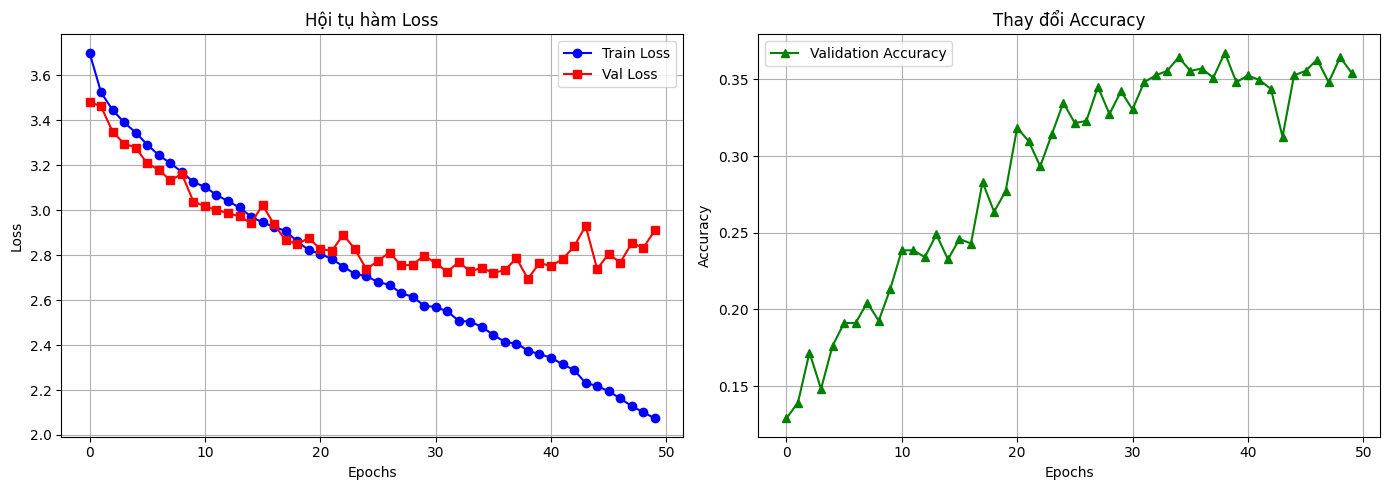

Đánh giá trên tập Test:


Testing: 100%|██████████| 43/43 [00:01<00:00, 24.23it/s]


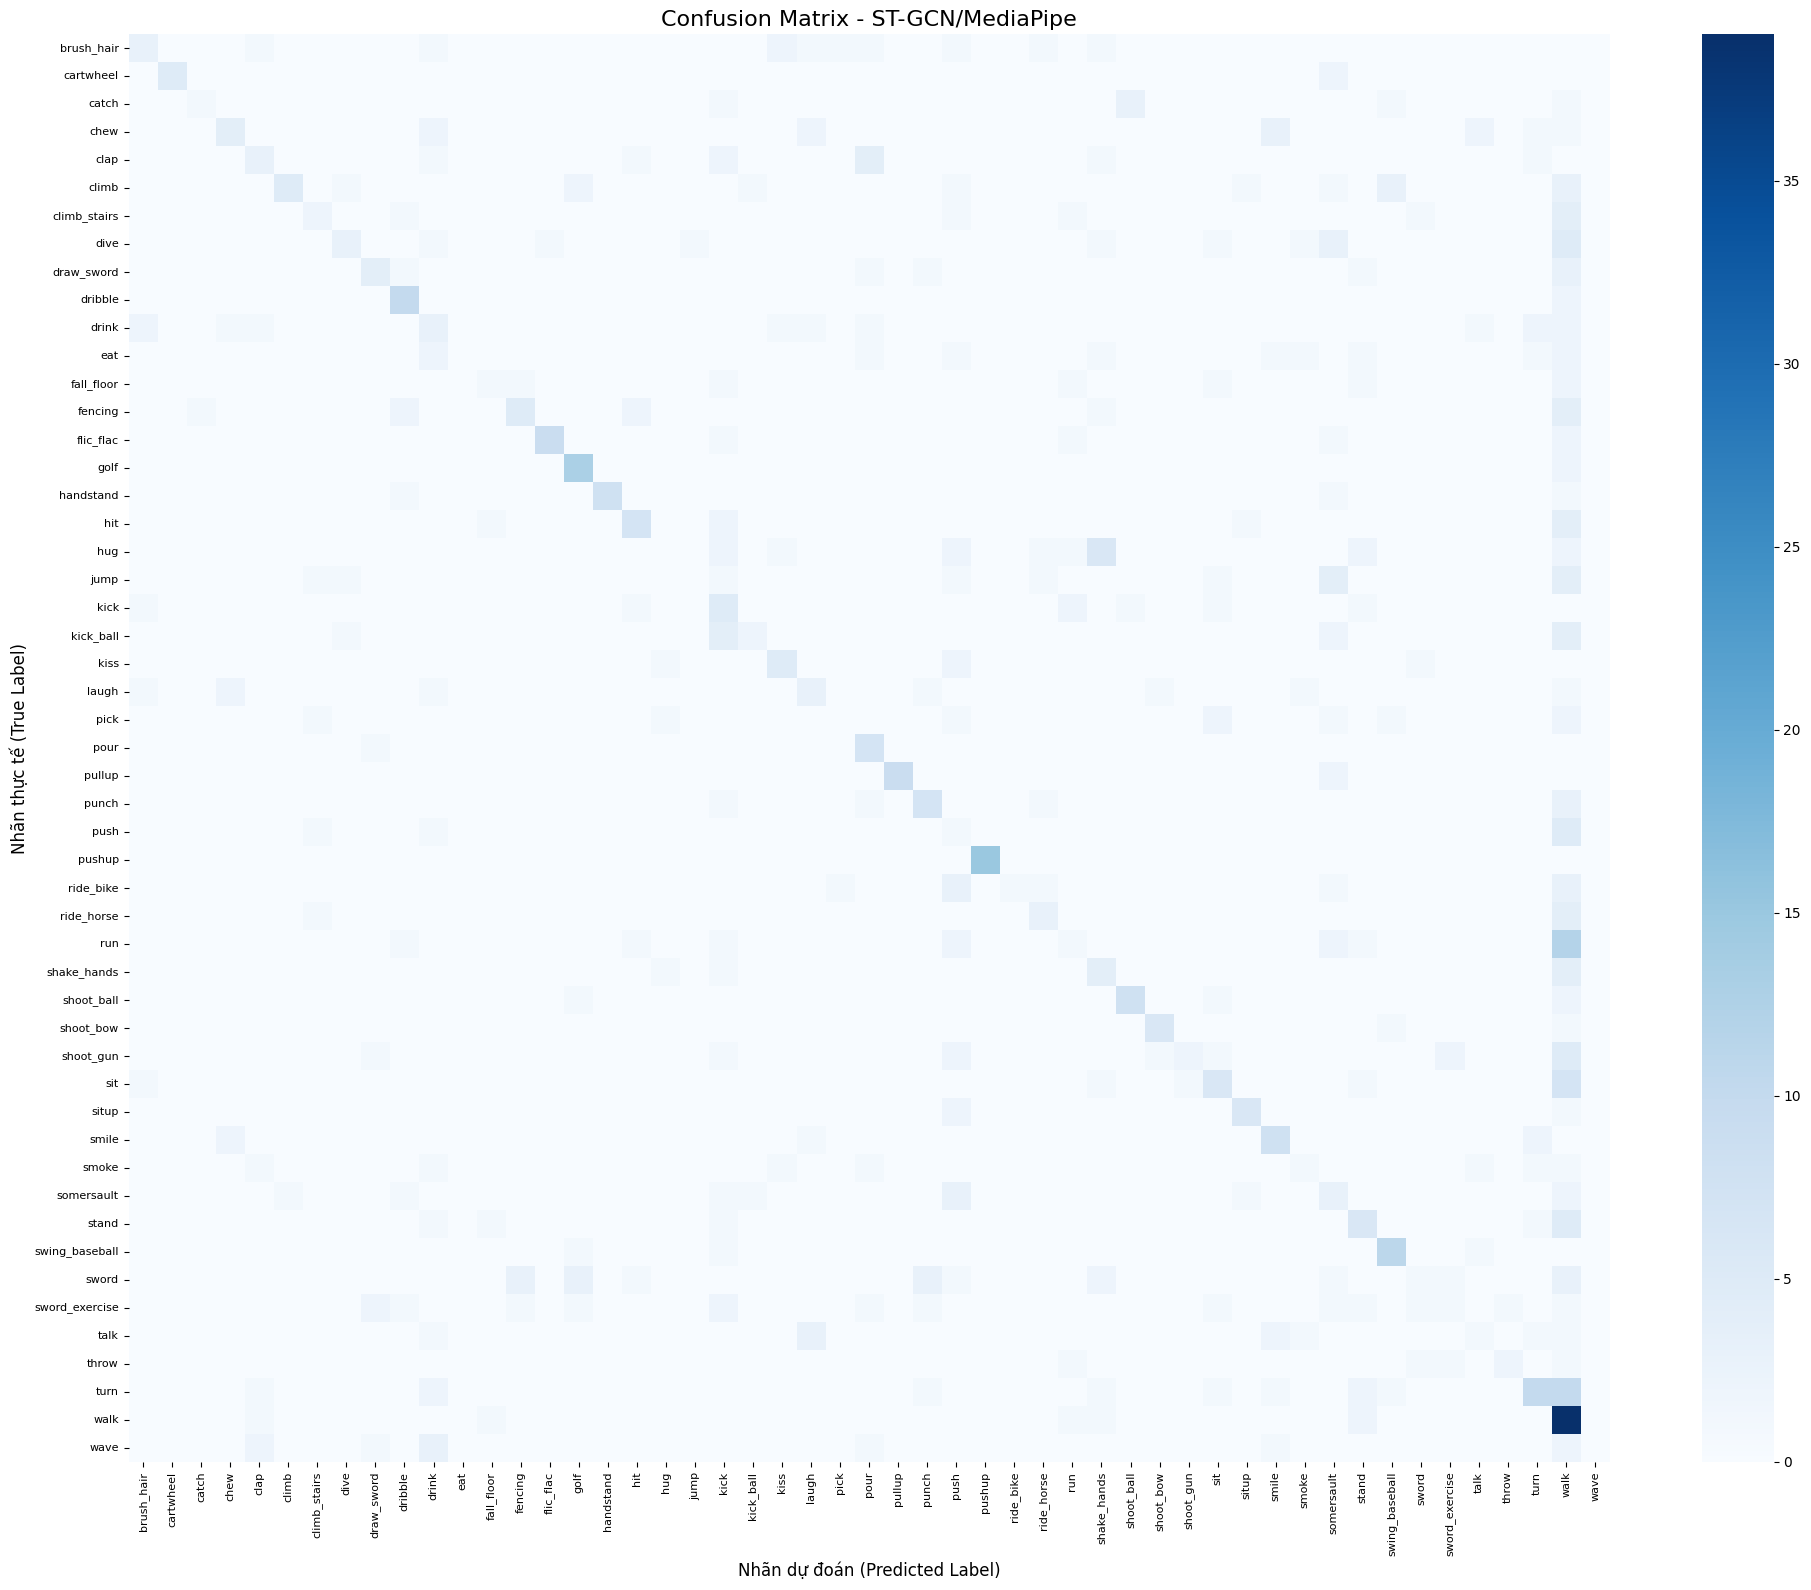


Báo cáo phân loại:
                precision    recall  f1-score   support

    brush_hair       0.38      0.23      0.29        13
     cartwheel       1.00      0.71      0.83         7
         catch       0.50      0.14      0.22         7
          chew       0.44      0.27      0.33        15
          clap       0.30      0.23      0.26        13
         climb       0.83      0.28      0.42        18
  climb_stairs       0.33      0.20      0.25        10
          dive       0.50      0.18      0.26        17
    draw_sword       0.44      0.36      0.40        11
       dribble       0.56      0.83      0.67        12
         drink       0.15      0.20      0.17        15
           eat       0.00      0.00      0.00        11
    fall_floor       0.25      0.12      0.17         8
       fencing       0.50      0.33      0.40        15
     flic_flac       0.90      0.64      0.75        14
          golf       0.62      0.87      0.72        15
     handstand       1.00  

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# biểu đồ loss vào accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss
ax1.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', color='red', marker='s')
ax1.set_title('Hội tụ hàm Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# accuracy
ax2.plot(history['val_acc'], label='Validation Accuracy', color='green', marker='^')
ax2.set_title('Thay đổi Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('model/stgcn_training_charts.png')
plt.show()

# chạy suy luận trên tập test để tạo confusion matrix
print("Đánh giá trên tập Test:")
# Load best weight
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# vẽ matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=all_classes, yticklabels=all_classes)
plt.title('Confusion Matrix - ST-GCN/MediaPipe', fontsize=16)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('model/stgcn_confusion_matrix.png')
plt.show()

# in báo cáo phân loại
print("\nBáo cáo phân loại:")
print(classification_report(all_labels, all_preds, target_names=all_classes, zero_division=0))